# Truco $R_B/R_C$ vs $\beta$ para determinar el estado del BJT

**Asignatura:** Fundamentos de Electronica (2 GIERM)
**Tema:** Transistor BJT - Determinacion rapida del estado (activa vs saturacion)
**Fecha:** 2026-03-29

---

## Por que importa este truco

Cuando resuelves un circuito con BJT, el primer paso es **suponer el estado** del transistor (activa, saturacion o corte). Si supones mal, pierdes tiempo resolviendo un sistema de ecuaciones que luego falla en la verificacion.

Este truco te permite **predecir el estado correcto en 5 segundos** mirando solo las resistencias y $\beta$, antes de tocar una sola ecuacion.

**Regla:**
- Si $R_B / R_C < \beta$ --> probablemente **saturacion**
- Si $R_B / R_C > \beta$ --> probablemente **activa**

En este notebook derivamos **de donde sale** esta relacion, por que funciona, y como extenderla a circuitos mas complejos.

**Referencia:** Notebook completo del BJT en `notebooks/Electronica/01_transistor_bjt.ipynb`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.style.use('seaborn-v0_8-whitegrid')

# Paleta de colores consistente
C_PRIMARY = '#3498db'
C_DANGER  = '#e74c3c'
C_SUCCESS = '#2ecc71'
C_DARK    = '#2c3e50'
C_ORANGE  = '#f39c12'
C_PURPLE  = '#9b59b6'

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

## 1. El circuito base: polarizacion fija

El circuito mas simple con un BJT NPN:

```
        VCC
         |
        [RB]
         |
         +----> Base (B)
         |
        [BJT NPN]
         |         |
     Emisor (E)  Colector (C)
         |         |
        GND      [RC]
                   |
                  VCC
```

Mas precisamente: $V_{CC}$ se conecta a $R_B$ (que va a la base) y tambien a $R_C$ (que va al colector). El emisor va a tierra.

**Dos mallas independientes:**

**Malla de base (entrada):**
$$V_{CC} = R_B \cdot I_B + V_{BE}$$

**Malla de colector (salida):**
$$V_{CC} = R_C \cdot I_C + V_{CE}$$

## 2. Derivacion matematica completa

### Paso 1: Calcular $I_B$ (siempre es lo primero)

De la malla de base, suponiendo que el transistor conduce ($V_{BE} \approx 0.7$ V en activa):

$$I_B = \frac{V_{CC} - V_{BE}}{R_B}$$

Donde:
- $V_{CC}$: tension de alimentacion (ej: 10 V)
- $V_{BE}$: caida base-emisor (0.7 V en activa, 0.8 V en saturacion)
- $R_B$: resistencia de base (ej: 100 k$\Omega$)
- $I_B$: corriente de base resultante

**Simplificacion clave:** Como $V_{CC} \gg V_{BE}$ en la mayoria de circuitos (10 V $\gg$ 0.7 V), podemos aproximar:

$$\boxed{I_B \approx \frac{V_{CC}}{R_B}}$$

### Paso 2: Calcular la $I_C$ que el transistor "quiere" dar en activa

Si el transistor esta en activa, $I_C = \beta \cdot I_B$:

$$I_{C,\text{activa}} = \beta \cdot I_B \approx \beta \cdot \frac{V_{CC}}{R_B}$$

### Paso 3: Calcular la $I_C$ maxima que el circuito permite (saturacion)

En saturacion, $V_{CE} = V_{CE_{sat}} \approx 0.2$ V. De la malla de colector:

$$I_{C,\text{sat}} = \frac{V_{CC} - V_{CE_{sat}}}{R_C}$$

Como $V_{CC} \gg V_{CE_{sat}}$:

$$\boxed{I_{C,\text{sat}} \approx \frac{V_{CC}}{R_C}}$$

### Paso 4: Comparar ambas corrientes (aqui esta la clave)

El transistor **satura cuando la corriente que "quiere" dar** ($\beta \cdot I_B$) **es mayor que la corriente maxima que el circuito permite** ($V_{CC}/R_C$):

$$\text{Saturacion cuando: } I_{C,\text{activa}} > I_{C,\text{sat}}$$

$$\beta \cdot \frac{V_{CC}}{R_B} > \frac{V_{CC}}{R_C}$$

Los $V_{CC}$ se **cancelan** (por eso el truco no depende de la tension de alimentacion):

$$\frac{\beta}{R_B} > \frac{1}{R_C}$$

Multiplicando ambos lados por $R_B$:

$$\beta > \frac{R_B}{R_C}$$

O equivalentemente:

$$\boxed{\frac{R_B}{R_C} < \beta \implies \text{SATURACION}}$$

$$\boxed{\frac{R_B}{R_C} > \beta \implies \text{ACTIVA}}$$

### Resumen de la derivacion

| Paso | Expresion | Significado |
|:----:|:---------:|:-----------:|
| 1 | $I_B \approx V_{CC}/R_B$ | Corriente que entra por la base |
| 2 | $I_{C,act} = \beta \cdot V_{CC}/R_B$ | Corriente que el transistor "quiere" dar |
| 3 | $I_{C,sat} = V_{CC}/R_C$ | Corriente maxima que permite el circuito |
| 4 | Si $I_{C,act} > I_{C,sat}$ | Satura (no puede dar toda la corriente) |
| 5 | Simplificando: $R_B/R_C < \beta$ | **Regla final** |

## 3. Ejemplo numerico 1: $R_B/R_C < \beta$ --> Saturacion

**Datos:** $V_{CC} = 10$ V, $R_B = 100$ k$\Omega$, $R_C = 3$ k$\Omega$, $\beta = 100$

**Paso 1: Aplicar el truco**

$$\frac{R_B}{R_C} = \frac{100\text{k}}{3\text{k}} = 33.3$$

Como $33.3 < 100 = \beta$ --> **prediccion: SATURACION**

**Paso 2: Verificar resolviendo el circuito**

Supongamos activa ($V_{BE} = 0.7$ V):

$$I_B = \frac{10 - 0.7}{100\text{k}} = 93\;\mu\text{A}$$

$$I_C = \beta \cdot I_B = 100 \times 93\;\mu\text{A} = 9.3\;\text{mA}$$

$$V_{CE} = V_{CC} - R_C \cdot I_C = 10 - 3\text{k} \times 9.3\text{mA} = 10 - 27.9 = -17.9\;\text{V}$$

$V_{CE}$ es **negativo** --> imposible --> la hipotesis de activa **FALLA**.

Ahora supongamos saturacion ($V_{BE} = 0.8$ V, $V_{CE} = 0.2$ V):

$$I_B = \frac{10 - 0.8}{100\text{k}} = 92\;\mu\text{A}$$

$$I_C = \frac{V_{CC} - V_{CE_{sat}}}{R_C} = \frac{10 - 0.2}{3\text{k}} = 3.27\;\text{mA}$$

Verificar: $I_C = 3.27\;\text{mA} < \beta \cdot I_B = 100 \times 92\;\mu\text{A} = 9.2\;\text{mA}$ --> **SATURACION confirmada**

El truco acerto.

In [2]:
# --- Ejemplo 1: RB/RC < beta --> Saturacion ---
VCC = 10
RB = 100e3
RC = 3e3
beta = 100

ratio = RB / RC
print(f"=== EJEMPLO 1: Saturacion ===")
print(f"  VCC = {VCC} V, RB = {RB/1e3:.0f} kOhm, RC = {RC/1e3:.0f} kOhm, beta = {beta}")
print(f"  RB/RC = {ratio:.1f}")
print(f"  beta  = {beta}")
print(f"  RB/RC < beta? {ratio} < {beta}? --> {'SI --> Prediccion: SATURACION' if ratio < beta else 'NO --> Prediccion: ACTIVA'}")

print(f"\n--- Verificacion suponiendo ACTIVA ---")
IB_act = (VCC - 0.7) / RB
IC_act = beta * IB_act
VCE_act = VCC - RC * IC_act
print(f"  IB = (VCC - 0.7) / RB = ({VCC} - 0.7) / {RB/1e3:.0f}k = {IB_act*1e6:.1f} uA")
print(f"  IC = beta * IB = {beta} x {IB_act*1e6:.1f} uA = {IC_act*1e3:.2f} mA")
print(f"  VCE = VCC - RC*IC = {VCC} - {RC/1e3:.0f}k x {IC_act*1e3:.2f}mA = {VCE_act:.2f} V")
print(f"  VCE = {VCE_act:.2f} V --> {'NEGATIVO! Imposible. Activa FALLA.' if VCE_act < 0.2 else 'OK, activa valida.'}")

print(f"\n--- Verificacion suponiendo SATURACION ---")
IB_sat = (VCC - 0.8) / RB
IC_sat = (VCC - 0.2) / RC
print(f"  IB = (VCC - 0.8) / RB = {IB_sat*1e6:.1f} uA")
print(f"  IC = (VCC - VCEsat) / RC = ({VCC} - 0.2) / {RC/1e3:.0f}k = {IC_sat*1e3:.2f} mA")
print(f"  beta*IB = {beta} x {IB_sat*1e6:.1f} uA = {beta*IB_sat*1e3:.2f} mA")
print(f"  IC < beta*IB? {IC_sat*1e3:.2f} < {beta*IB_sat*1e3:.2f}? --> {'SI --> SATURACION CONFIRMADA' if IC_sat < beta*IB_sat else 'NO --> Falla'}")

=== EJEMPLO 1: Saturacion ===
  VCC = 10 V, RB = 100 kOhm, RC = 3 kOhm, beta = 100
  RB/RC = 33.3
  beta  = 100
  RB/RC < beta? 33.333333333333336 < 100? --> SI --> Prediccion: SATURACION

--- Verificacion suponiendo ACTIVA ---
  IB = (VCC - 0.7) / RB = (10 - 0.7) / 100k = 93.0 uA
  IC = beta * IB = 100 x 93.0 uA = 9.30 mA
  VCE = VCC - RC*IC = 10 - 3k x 9.30mA = -17.90 V
  VCE = -17.90 V --> NEGATIVO! Imposible. Activa FALLA.

--- Verificacion suponiendo SATURACION ---
  IB = (VCC - 0.8) / RB = 92.0 uA
  IC = (VCC - VCEsat) / RC = (10 - 0.2) / 3k = 3.27 mA
  beta*IB = 100 x 92.0 uA = 9.20 mA
  IC < beta*IB? 3.27 < 9.20? --> SI --> SATURACION CONFIRMADA


## 4. Ejemplo numerico 2: $R_B/R_C > \beta$ --> Activa

**Datos:** $V_{CC} = 10$ V, $R_B = 330$ k$\Omega$, $R_C = 1$ k$\Omega$, $\beta = 100$

**Paso 1: Aplicar el truco**

$$\frac{R_B}{R_C} = \frac{330\text{k}}{1\text{k}} = 330$$

Como $330 > 100 = \beta$ --> **prediccion: ACTIVA**

**Paso 2: Verificar resolviendo el circuito**

Supongamos activa ($V_{BE} = 0.7$ V):

$$I_B = \frac{10 - 0.7}{330\text{k}} = 28.2\;\mu\text{A}$$

$$I_C = \beta \cdot I_B = 100 \times 28.2\;\mu\text{A} = 2.82\;\text{mA}$$

$$V_{CE} = V_{CC} - R_C \cdot I_C = 10 - 1\text{k} \times 2.82\text{mA} = 10 - 2.82 = 7.18\;\text{V}$$

$V_{CE} = 7.18$ V $> V_{CE_{sat}} = 0.2$ V --> **ACTIVA confirmada**

El truco acerto de nuevo.

In [3]:
# --- Ejemplo 2: RB/RC > beta --> Activa ---
VCC = 10
RB = 330e3
RC = 1e3
beta = 100

ratio = RB / RC
print(f"=== EJEMPLO 2: Activa ===")
print(f"  VCC = {VCC} V, RB = {RB/1e3:.0f} kOhm, RC = {RC/1e3:.0f} kOhm, beta = {beta}")
print(f"  RB/RC = {ratio:.1f}")
print(f"  beta  = {beta}")
print(f"  RB/RC < beta? {ratio} < {beta}? --> {'SI --> Prediccion: SATURACION' if ratio < beta else 'NO --> Prediccion: ACTIVA'}")

print(f"\n--- Verificacion suponiendo ACTIVA ---")
IB = (VCC - 0.7) / RB
IC = beta * IB
VCE = VCC - RC * IC
print(f"  IB = ({VCC} - 0.7) / {RB/1e3:.0f}k = {IB*1e6:.1f} uA")
print(f"  IC = {beta} x {IB*1e6:.1f} uA = {IC*1e3:.2f} mA")
print(f"  VCE = {VCC} - {RC/1e3:.0f}k x {IC*1e3:.2f}mA = {VCE:.2f} V")
print(f"  VCE = {VCE:.2f} V > 0.2 V? --> {'SI --> ACTIVA CONFIRMADA' if VCE > 0.2 else 'NO --> Falla'}")

=== EJEMPLO 2: Activa ===
  VCC = 10 V, RB = 330 kOhm, RC = 1 kOhm, beta = 100
  RB/RC = 330.0
  beta  = 100
  RB/RC < beta? 330.0 < 100? --> NO --> Prediccion: ACTIVA

--- Verificacion suponiendo ACTIVA ---
  IB = (10 - 0.7) / 330k = 28.2 uA
  IC = 100 x 28.2 uA = 2.82 mA
  VCE = 10 - 1k x 2.82mA = 7.18 V
  VCE = 7.18 V > 0.2 V? --> SI --> ACTIVA CONFIRMADA


## 5. Visualizacion: mapa de estados en funcion de $R_B/R_C$ y $\beta$

La siguiente grafica muestra la **frontera** entre activa y saturacion. La linea diagonal es donde $R_B/R_C = \beta$. Todo lo que queda **por debajo** (ratio menor que beta) es saturacion.

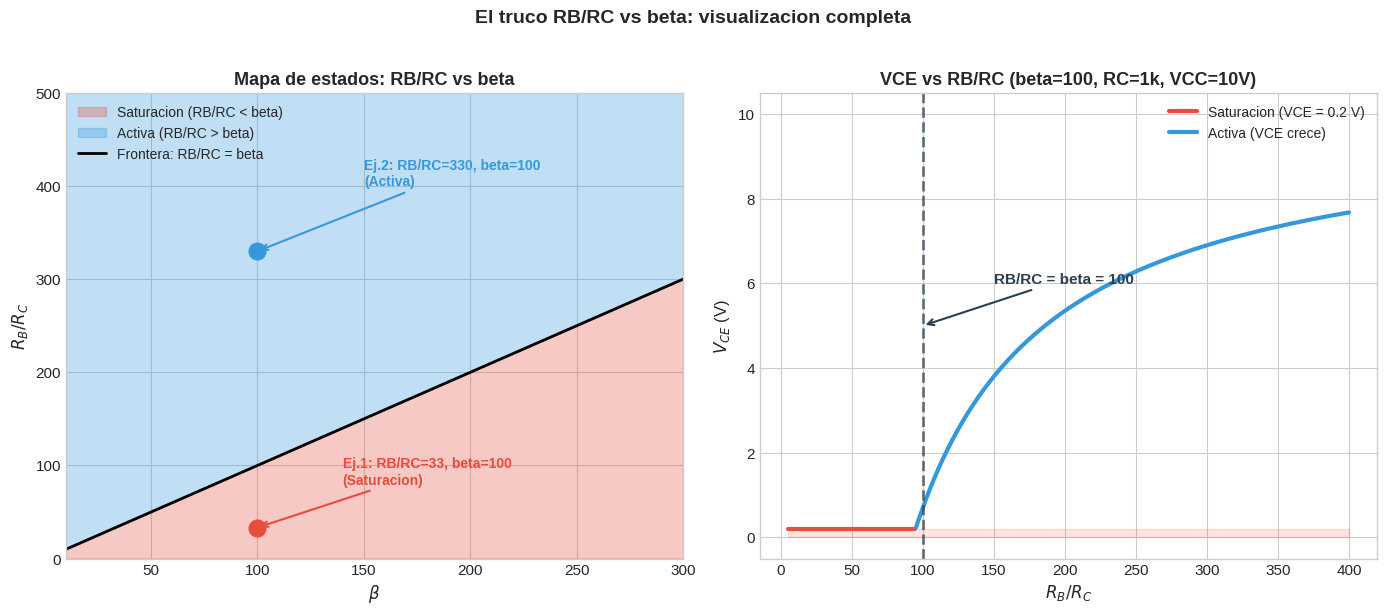

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Panel 1: Mapa de estados RB/RC vs beta ---
ax = axes[0]
beta_range = np.linspace(10, 300, 300)
ax.fill_between(beta_range, 0, beta_range, alpha=0.3, color=C_DANGER, label='Saturacion (RB/RC < beta)')
ax.fill_between(beta_range, beta_range, 500, alpha=0.3, color=C_PRIMARY, label='Activa (RB/RC > beta)')
ax.plot(beta_range, beta_range, 'k-', lw=2, label='Frontera: RB/RC = beta')

# Marcar los dos ejemplos
ax.plot(100, 33.3, 'o', color=C_DANGER, ms=12, zorder=5)
ax.annotate('Ej.1: RB/RC=33, beta=100\n(Saturacion)', xy=(100, 33.3),
            xytext=(140, 80), fontsize=10, fontweight='bold', color=C_DANGER,
            arrowprops=dict(arrowstyle='->', color=C_DANGER, lw=1.5))

ax.plot(100, 330, 'o', color=C_PRIMARY, ms=12, zorder=5)
ax.annotate('Ej.2: RB/RC=330, beta=100\n(Activa)', xy=(100, 330),
            xytext=(150, 400), fontsize=10, fontweight='bold', color=C_PRIMARY,
            arrowprops=dict(arrowstyle='->', color=C_PRIMARY, lw=1.5))

ax.set_xlabel(r'$\beta$', fontsize=12)
ax.set_ylabel(r'$R_B / R_C$', fontsize=12)
ax.set_title('Mapa de estados: RB/RC vs beta', fontsize=13, fontweight='bold')
ax.set_xlim(10, 300)
ax.set_ylim(0, 500)
ax.legend(fontsize=10, loc='upper left')

# --- Panel 2: VCE vs RB/RC para beta fijo ---
ax2 = axes[1]
beta_fijo = 100
VCC = 10
RC_fijo = 1e3  # 1 kOhm

ratios = np.linspace(5, 400, 500)
RB_vals = ratios * RC_fijo

VCE_vals = []
estados = []
for rb in RB_vals:
    IB = (VCC - 0.7) / rb
    IC_activa = beta_fijo * IB
    VCE_calc = VCC - RC_fijo * IC_activa
    if VCE_calc >= 0.2:
        VCE_vals.append(VCE_calc)
        estados.append('activa')
    else:
        VCE_vals.append(0.2)  # saturacion
        estados.append('sat')

VCE_vals = np.array(VCE_vals)
colores = [C_DANGER if e == 'sat' else C_PRIMARY for e in estados]

# Dibujar por tramos
mask_sat = np.array([e == 'sat' for e in estados])
mask_act = ~mask_sat

ax2.fill_between(ratios, 0, 0.2, alpha=0.15, color=C_DANGER)
ax2.plot(ratios[mask_sat], VCE_vals[mask_sat], '-', color=C_DANGER, lw=3, label='Saturacion (VCE = 0.2 V)')
ax2.plot(ratios[mask_act], VCE_vals[mask_act], '-', color=C_PRIMARY, lw=3, label='Activa (VCE crece)')
ax2.axvline(x=beta_fijo, color=C_DARK, ls='--', lw=2, alpha=0.7)
ax2.annotate(f'RB/RC = beta = {beta_fijo}', xy=(beta_fijo, 5),
             xytext=(beta_fijo + 50, 6), fontsize=11, fontweight='bold', color=C_DARK,
             arrowprops=dict(arrowstyle='->', color=C_DARK, lw=1.5))

ax2.set_xlabel(r'$R_B / R_C$', fontsize=12)
ax2.set_ylabel(r'$V_{CE}$ (V)', fontsize=12)
ax2.set_title(f'VCE vs RB/RC (beta={beta_fijo}, RC=1k, VCC=10V)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_ylim(-0.5, 10.5)

plt.suptitle('El truco RB/RC vs beta: visualizacion completa', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Intuicion: por que funciona este truco

### Analogia del grifo y la tuberia

Imagina que $\beta \cdot I_B$ es el **caudal de agua que un grifo quiere soltar** y $V_{CC}/R_C$ es el **diametro maximo de la tuberia** (la corriente maxima que el circuito permite).

- **Si el grifo quiere soltar mas agua de la que la tuberia puede llevar** ($\beta \cdot I_B > V_{CC}/R_C$): la tuberia se "llena" al maximo. El transistor **satura** -- da toda la corriente que puede pero no mas. $V_{CE}$ cae al minimo (0.2 V).

- **Si el grifo soltar menos agua de la que cabe en la tuberia** ($\beta \cdot I_B < V_{CC}/R_C$): la tuberia tiene holgura. El transistor trabaja en **activa** -- da exactamente $\beta \cdot I_B$ y queda tension sobrante en $V_{CE}$.

### Por que $V_{CC}$ se cancela

Fijate que $V_{CC}$ aparece **tanto en el numerador de $I_B$** (mas VCC = mas corriente de base) **como en el numerador de $I_{C,sat}$** (mas VCC = mas corriente maxima permitida). Al comparar, se cancela. Es como decir: "si subes la presion del agua, el grifo da mas pero la tuberia tambien aguanta mas".

### Que significa fisicamente cada caso

| Condicion | $R_B$ es... | $R_C$ es... | Resultado |
|:---------:|:-----------:|:-----------:|:---------:|
| $R_B/R_C \ll \beta$ | Pequena (mucha $I_B$) | Grande (poca $I_{C,max}$) | Saturacion segura |
| $R_B/R_C \approx \beta$ | Zona frontera | Zona frontera | Caso limite (verificar) |
| $R_B/R_C \gg \beta$ | Grande (poca $I_B$) | Pequena (mucha $I_{C,max}$) | Activa segura |

**Clave conceptual:** $R_B$ controla "cuanto empujas" al transistor (base). $R_C$ controla "cuanto le dejas dar" (colector). Si empujas mucho y le dejas dar poco --> satura.

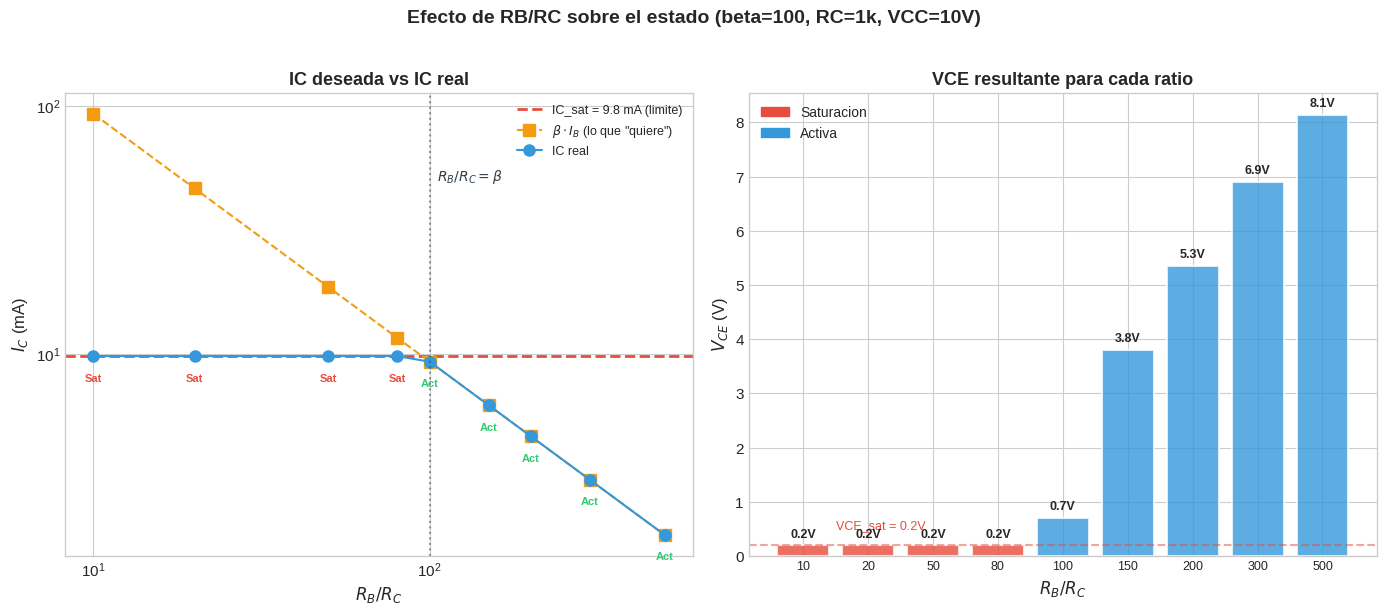

In [5]:
# --- Visualizacion: barrido de RB con RC fijo, mostrando la transicion ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

VCC = 10
RC = 1e3
beta = 100

RB_values = np.array([10, 20, 50, 80, 100, 150, 200, 300, 500]) * 1e3

IC_activa_vals = []
IC_real_vals = []
VCE_vals = []
estados = []

for rb in RB_values:
    IB = (VCC - 0.7) / rb
    IC_want = beta * IB
    IC_max = (VCC - 0.2) / RC
    if IC_want <= IC_max:
        IC_real_vals.append(IC_want)
        VCE_vals.append(VCC - RC * IC_want)
        estados.append('Activa')
    else:
        IC_real_vals.append(IC_max)
        VCE_vals.append(0.2)
        estados.append('Saturacion')
    IC_activa_vals.append(IC_want)

IC_activa_vals = np.array(IC_activa_vals) * 1e3
IC_real_vals = np.array(IC_real_vals) * 1e3
VCE_vals = np.array(VCE_vals)
ratios = RB_values / RC

# Panel 1: Corrientes
ax1 = axes[0]
ax1.axhline(y=(VCC-0.2)/RC*1e3, color=C_DANGER, ls='--', lw=2, label=f'IC_sat = {(VCC-0.2)/RC*1e3:.1f} mA (limite)')
ax1.plot(ratios, IC_activa_vals, 's--', color=C_ORANGE, ms=8, label=r'$\beta \cdot I_B$ (lo que "quiere")')
ax1.plot(ratios, IC_real_vals, 'o-', color=C_PRIMARY, ms=8, label='IC real')

for i, (r, ic_w, ic_r, est) in enumerate(zip(ratios, IC_activa_vals, IC_real_vals, estados)):
    color = C_DANGER if est == 'Saturacion' else C_SUCCESS
    ax1.annotate(est[:3], xy=(r, ic_r), xytext=(0, -18), textcoords='offset points',
                fontsize=8, fontweight='bold', color=color, ha='center')

ax1.axvline(x=beta, color=C_DARK, ls=':', lw=1.5, alpha=0.5)
ax1.text(beta + 5, 50, r'$R_B/R_C = \beta$', fontsize=10, color=C_DARK)
ax1.set_xlabel(r'$R_B / R_C$', fontsize=12)
ax1.set_ylabel(r'$I_C$ (mA)', fontsize=12)
ax1.set_title('IC deseada vs IC real', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_xscale('log')
ax1.set_yscale('log')

# Panel 2: VCE
ax2 = axes[1]
colors_bar = [C_DANGER if e == 'Saturacion' else C_PRIMARY for e in estados]
bars = ax2.bar(range(len(ratios)), VCE_vals, color=colors_bar, alpha=0.8, edgecolor='white', lw=1.5)
ax2.set_xticks(range(len(ratios)))
ax2.set_xticklabels([f'{r:.0f}' for r in ratios], fontsize=9)
ax2.set_xlabel(r'$R_B / R_C$', fontsize=12)
ax2.set_ylabel(r'$V_{CE}$ (V)', fontsize=12)
ax2.set_title('VCE resultante para cada ratio', fontsize=13, fontweight='bold')
ax2.axhline(y=0.2, color=C_DANGER, ls='--', lw=1.5, alpha=0.5)
ax2.text(0.5, 0.5, 'VCE_sat = 0.2V', fontsize=9, color=C_DANGER)

# Leyenda manual
legend_patches = [
    mpatches.Patch(color=C_DANGER, label='Saturacion'),
    mpatches.Patch(color=C_PRIMARY, label='Activa'),
]
ax2.legend(handles=legend_patches, fontsize=10)

for i, (v, e) in enumerate(zip(VCE_vals, estados)):
    ax2.text(i, v + 0.15, f'{v:.1f}V', ha='center', fontsize=9, fontweight='bold')

plt.suptitle(f'Efecto de RB/RC sobre el estado (beta={beta}, RC={RC/1e3:.0f}k, VCC={VCC}V)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. El $\beta$ critico: valor exacto de la frontera

Para polarizacion fija, podemos calcular el **valor exacto de $\beta$** en el que el transistor pasa de activa a saturacion.

En el limite exacto, $V_{CE} = V_{CE_{sat}}$:

$$V_{CC} - R_C \cdot \beta_{crit} \cdot I_B = V_{CE_{sat}}$$

$$\beta_{crit} = \frac{V_{CC} - V_{CE_{sat}}}{R_C \cdot I_B} = \frac{V_{CC} - V_{CE_{sat}}}{R_C} \cdot \frac{R_B}{V_{CC} - V_{BE}}$$

Con la aproximacion ($V_{CC} \gg V_{BE}$ y $V_{CC} \gg V_{CE_{sat}}$):

$$\boxed{\beta_{crit} \approx \frac{R_B}{R_C}}$$

Ejemplo con los datos del notebook de referencia: $V_{CC} = 5$ V, $R_B = 10$ k$\Omega$, $R_C = 1$ k$\Omega$

$$\beta_{crit,exacto} = \frac{5 - 0.2}{1\text{k}} \cdot \frac{10\text{k}}{5 - 0.7} = \frac{4.8}{1\text{k}} \cdot \frac{10\text{k}}{4.3} = 11.16$$

$$\beta_{crit,aprox} = \frac{R_B}{R_C} = \frac{10\text{k}}{1\text{k}} = 10$$

Son muy cercanos (11.16 vs 10). La aproximacion funciona bien cuando $V_{CC}$ es grande.

RB/RC = 10 (aproximacion constante)
beta_crit exacto con VCC=5V:  11.16
beta_crit exacto con VCC=10V: 10.54
beta_crit exacto con VCC=20V: 10.26

Conclusion: a mayor VCC, la aproximacion es mas precisa.


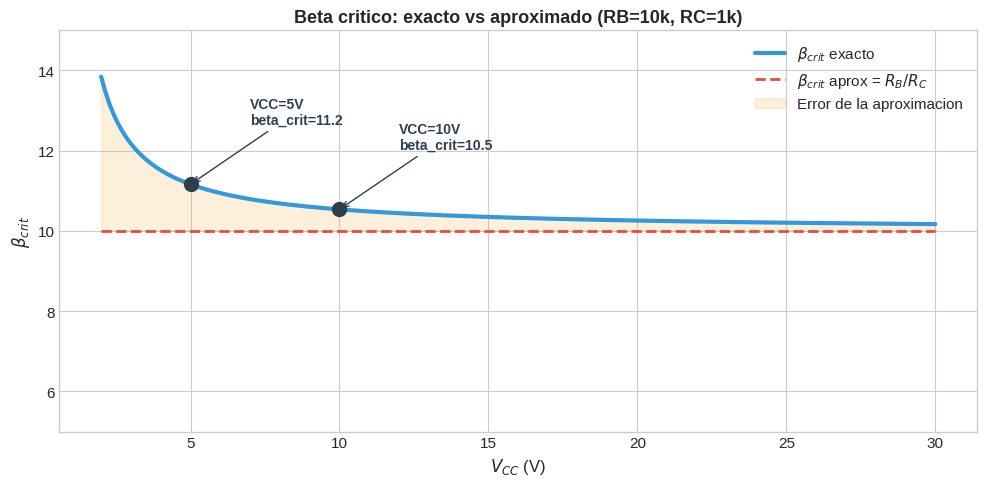

In [6]:
# --- Beta critico: exacto vs aproximado para distintos VCC ---
fig, ax = plt.subplots(figsize=(10, 5))

RB = 10e3
RC = 1e3
VBE = 0.7
VCE_sat = 0.2

VCC_range = np.linspace(2, 30, 200)
beta_crit_exacto = ((VCC_range - VCE_sat) / RC) * (RB / (VCC_range - VBE))
beta_crit_aprox = np.full_like(VCC_range, RB / RC)

ax.plot(VCC_range, beta_crit_exacto, '-', color=C_PRIMARY, lw=3, label=r'$\beta_{crit}$ exacto')
ax.plot(VCC_range, beta_crit_aprox, '--', color=C_DANGER, lw=2, label=r'$\beta_{crit}$ aprox = $R_B/R_C$')

ax.fill_between(VCC_range, beta_crit_exacto, beta_crit_aprox, alpha=0.15, color=C_ORANGE,
                label='Error de la aproximacion')

# Marcar VCC = 5V y VCC = 10V
for vcc_mark in [5, 10]:
    beta_ex = ((vcc_mark - VCE_sat) / RC) * (RB / (vcc_mark - VBE))
    ax.plot(vcc_mark, beta_ex, 'o', color=C_DARK, ms=10, zorder=5)
    ax.annotate(f'VCC={vcc_mark}V\nbeta_crit={beta_ex:.1f}',
                xy=(vcc_mark, beta_ex), xytext=(vcc_mark+2, beta_ex+1.5),
                fontsize=10, fontweight='bold', color=C_DARK,
                arrowprops=dict(arrowstyle='->', color=C_DARK))

ax.set_xlabel(r'$V_{CC}$ (V)', fontsize=12)
ax.set_ylabel(r'$\beta_{crit}$', fontsize=12)
ax.set_title(f'Beta critico: exacto vs aproximado (RB={RB/1e3:.0f}k, RC={RC/1e3:.0f}k)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(5, 15)

print(f"RB/RC = {RB/RC:.0f} (aproximacion constante)")
print(f"beta_crit exacto con VCC=5V:  {((5-0.2)/RC)*(RB/(5-0.7)):.2f}")
print(f"beta_crit exacto con VCC=10V: {((10-0.2)/RC)*(RB/(10-0.7)):.2f}")
print(f"beta_crit exacto con VCC=20V: {((20-0.2)/RC)*(RB/(20-0.7)):.2f}")
print(f"\nConclusion: a mayor VCC, la aproximacion es mas precisa.")

plt.tight_layout()
plt.show()

## 8. Extension a circuitos mas complejos

El truco $R_B/R_C < \beta$ es exacto solo para **polarizacion fija sin $R_E$**. Para otros circuitos, la idea es la misma pero hay que adaptar las expresiones.

### 8.1 Con $R_E$ (sin divisor de tension)

Las mallas cambian:
- **Base:** $V_{CC} = R_B \cdot I_B + V_{BE} + R_E \cdot (I_B + I_C)$
- **Colector:** $V_{CC} = R_C \cdot I_C + V_{CE} + R_E \cdot (I_B + I_C)$

En activa ($I_C = \beta I_B$) la malla de base da:

$$I_B = \frac{V_{CC} - V_{BE}}{R_B + (1+\beta) \cdot R_E}$$

La corriente maxima en saturacion:

$$I_{C,sat} \approx \frac{V_{CC} - V_{CE_{sat}}}{R_C + R_E}$$

El truco adaptado se convierte en comparar:

$$\beta \cdot \frac{V_{CC}}{R_B + (1+\beta) R_E} \quad \text{vs} \quad \frac{V_{CC}}{R_C + R_E}$$

Simplificando (para $\beta$ grande, $(1+\beta) \approx \beta$):

$$\boxed{\frac{R_B + \beta \cdot R_E}{R_C + R_E} \lessgtr \beta}$$

- Si el ratio es **menor** que $\beta$ --> saturacion
- Si es **mayor** --> activa

**Nota:** $R_E$ aparece en ambos lados, haciendo mas dificil saturar (la $R_E$ estabiliza).

### 8.2 Con divisor de tension ($R_1$, $R_2$, $R_C$, $R_E$)

Se usa el equivalente Thevenin visto desde la base:

$$V_{TH} = V_{CC} \cdot \frac{R_2}{R_1 + R_2}, \quad R_{TH} = R_1 \| R_2 = \frac{R_1 \cdot R_2}{R_1 + R_2}$$

Ahora el circuito equivalente es como polarizacion fija pero con $V_{TH}$ y $R_{TH}$:

$$I_B = \frac{V_{TH} - V_{BE}}{R_{TH} + (1+\beta) R_E}$$

La condicion de saturacion se convierte en:

$$\beta \cdot I_B > I_{C,sat} = \frac{V_{CC} - V_{CE_{sat}}}{R_C + R_E}$$

Aqui **no se puede simplificar tan limpiamente** porque $V_{TH} \neq V_{CC}$, asi que los $V_{CC}$ no se cancelan. Pero la **idea** es la misma:
1. Calcula $I_B$ con el Thevenin
2. Calcula $\beta \cdot I_B$ (lo que el transistor "quiere")
3. Calcula $I_{C,sat}$ (lo maximo que el circuito da)
4. Compara

### 8.3 Tabla resumen de adaptaciones

| Circuito | $I_B$ | $I_{C,sat}$ | Truco rapido |
|:--------:|:-----:|:-----------:|:------------:|
| Pol. fija | $\frac{V_{CC}}{R_B}$ | $\frac{V_{CC}}{R_C}$ | $R_B/R_C < \beta$ |
| Con $R_E$ | $\frac{V_{CC}}{R_B + \beta R_E}$ | $\frac{V_{CC}}{R_C + R_E}$ | $(R_B + \beta R_E)/(R_C + R_E) < \beta$ |
| Divisor + $R_E$ | $\frac{V_{TH}}{R_{TH} + \beta R_E}$ | $\frac{V_{CC}}{R_C + R_E}$ | Calcular numericamente |
| Dos fuentes | $\frac{V_{BB}}{R_B}$ | $\frac{V_{CC}}{R_C}$ | $\frac{R_B}{R_C} \cdot \frac{V_{CC}}{V_{BB}} < \beta$ |

In [7]:
# --- Funcion general para determinar estado en cualquier tipo de circuito ---

def determinar_estado_pol_fija(VCC, RB, RC, beta, VBE_act=0.7, VBE_sat=0.8, VCE_sat=0.2):
    """Polarizacion fija: VCC, RB, RC"""
    ratio = RB / RC
    prediccion = "Saturacion" if ratio < beta else "Activa"

    # Verificar con activa
    IB = (VCC - VBE_act) / RB
    IC = beta * IB
    VCE = VCC - RC * IC
    activa_ok = VCE > VCE_sat

    # Verificar con saturacion
    IB_s = (VCC - VBE_sat) / RB
    IC_s = (VCC - VCE_sat) / RC
    sat_ok = IC_s < beta * IB_s

    real = "Activa" if activa_ok else ("Saturacion" if sat_ok else "Corte")
    return prediccion, real, ratio

def determinar_estado_con_RE(VCC, RB, RC, RE, beta, VBE_act=0.7, VCE_sat=0.2):
    """Polarizacion fija con RE"""
    IB = (VCC - VBE_act) / (RB + (1 + beta) * RE)
    IC_want = beta * IB
    IC_sat = (VCC - VCE_sat) / (RC + RE)
    prediccion = "Saturacion" if IC_want > IC_sat else "Activa"

    VCE = VCC - (RC + RE) * IC_want - RE * IB  # simplificado
    VCE_check = VCC - RC * IC_want - RE * (IB + IC_want)
    real = "Activa" if VCE_check > VCE_sat else "Saturacion"
    return prediccion, real

def determinar_estado_divisor(VCC, R1, R2, RC, RE, beta, VBE_act=0.7, VCE_sat=0.2):
    """Divisor de tension con RE"""
    VTH = VCC * R2 / (R1 + R2)
    RTH = R1 * R2 / (R1 + R2)
    IB = (VTH - VBE_act) / (RTH + (1 + beta) * RE)
    IC_want = beta * IB
    IC_sat = (VCC - VCE_sat) / (RC + RE)
    prediccion = "Saturacion" if IC_want > IC_sat else "Activa"

    VCE = VCC - RC * IC_want - RE * (IB + IC_want)
    real = "Activa" if VCE > VCE_sat else "Saturacion"
    return prediccion, real

# --- Probar con multiples circuitos ---
print("=" * 70)
print("VERIFICACION DEL TRUCO EN DISTINTOS CIRCUITOS")
print("=" * 70)

print("\n--- Polarizacion fija ---")
casos_fija = [
    (10, 100e3, 3e3, 100, "Ej. notebook: RB=100k, RC=3k"),
    (10, 330e3, 1e3, 100, "RB=330k, RC=1k"),
    (10, 100e3, 1e3, 100, "RB=100k, RC=1k (frontera)"),
    (5, 10e3, 1e3, 50, "VCC=5V, RB=10k, RC=1k"),
    (12, 470e3, 2.2e3, 200, "VCC=12V, RB=470k, RC=2.2k"),
]
for vcc, rb, rc, b, desc in casos_fija:
    pred, real, ratio = determinar_estado_pol_fija(vcc, rb, rc, b)
    check = "OK" if pred == real else "FALLO"
    print(f"  {desc}")
    print(f"    RB/RC = {ratio:.1f}, beta = {b} --> Truco: {pred}, Real: {real} [{check}]")

print("\n--- Con RE ---")
casos_re = [
    (10, 100e3, 2e3, 500, 100, "RB=100k, RC=2k, RE=500"),
    (10, 50e3, 2e3, 1e3, 100, "RB=50k, RC=2k, RE=1k"),
    (10, 330e3, 1e3, 500, 100, "RB=330k, RC=1k, RE=500"),
]
for vcc, rb, rc, re, b, desc in casos_re:
    pred, real = determinar_estado_con_RE(vcc, rb, rc, re, b)
    check = "OK" if pred == real else "FALLO"
    print(f"  {desc}")
    print(f"    Truco: {pred}, Real: {real} [{check}]")

print("\n--- Divisor de tension ---")
casos_div = [
    (10, 10e3, 10e3, 5e3, 1e3, 150, "R1=R2=10k, RC=5k, RE=1k (ej. notebook)"),
    (12, 47e3, 10e3, 2.2e3, 1e3, 100, "R1=47k, R2=10k, RC=2.2k, RE=1k"),
    (10, 100e3, 10e3, 1e3, 500, 200, "R1=100k, R2=10k, RC=1k, RE=500"),
]
for vcc, r1, r2, rc, re, b, desc in casos_div:
    pred, real = determinar_estado_divisor(vcc, r1, r2, rc, re, b)
    check = "OK" if pred == real else "FALLO"
    print(f"  {desc}")
    print(f"    Truco: {pred}, Real: {real} [{check}]")

VERIFICACION DEL TRUCO EN DISTINTOS CIRCUITOS

--- Polarizacion fija ---
  Ej. notebook: RB=100k, RC=3k
    RB/RC = 33.3, beta = 100 --> Truco: Saturacion, Real: Saturacion [OK]
  RB=330k, RC=1k
    RB/RC = 330.0, beta = 100 --> Truco: Activa, Real: Activa [OK]
  RB=100k, RC=1k (frontera)
    RB/RC = 100.0, beta = 100 --> Truco: Activa, Real: Activa [OK]
  VCC=5V, RB=10k, RC=1k
    RB/RC = 10.0, beta = 50 --> Truco: Saturacion, Real: Saturacion [OK]
  VCC=12V, RB=470k, RC=2.2k
    RB/RC = 213.6, beta = 200 --> Truco: Activa, Real: Activa [OK]

--- Con RE ---
  RB=100k, RC=2k, RE=500
    Truco: Saturacion, Real: Saturacion [OK]
  RB=50k, RC=2k, RE=1k
    Truco: Saturacion, Real: Saturacion [OK]
  RB=330k, RC=1k, RE=500
    Truco: Activa, Real: Activa [OK]

--- Divisor de tension ---
  R1=R2=10k, RC=5k, RE=1k (ej. notebook)
    Truco: Saturacion, Real: Saturacion [OK]
  R1=47k, R2=10k, RC=2.2k, RE=1k
    Truco: Activa, Real: Activa [OK]
  R1=100k, R2=10k, RC=1k, RE=500
    Truco: Activa,

## 9. Limitaciones y casos donde el truco puede fallar

### Cuando funciona perfectamente
- Polarizacion fija (RB + RC, una fuente)
- $V_{CC}$ razonablemente grande (> 5V)
- Transistor NPN con emisor a tierra

### Cuando hay que tener cuidado
1. **$V_{CC}$ muy baja** (ej: 3.3V o 1.8V en logica digital): las aproximaciones $V_{CC} \gg V_{BE}$ y $V_{CC} \gg V_{CE_{sat}}$ dejan de ser validas. El beta critico exacto difiere mas del aproximado.

2. **$R_B/R_C \approx \beta$** (zona frontera): si el ratio esta muy cerca de $\beta$, podrias estar en el borde. **Siempre verifica** resolviendo el circuito en este caso.

3. **Circuitos con $R_E$ grande**: la $R_E$ crea realimentacion negativa que estabiliza el punto de operacion. Un circuito que "parece" que deberia saturar con el truco simple puede estar en activa gracias a $R_E$.

4. **Divisor de tension**: como $V_{TH} < V_{CC}$, la corriente de base es menor de lo que el truco simple predice. El divisor "protege" contra saturacion.

5. **Transistor PNP**: el truco funciona igual pero hay que invertir las convenciones de tension. La logica $R_B/R_C$ vs $\beta$ se mantiene.

### Regla practica final

> **En un examen:** usa el truco para hacer tu hipotesis inicial. Siempre verifica al final.
> Si $R_B/R_C$ esta lejos de $\beta$ (factor 2x o mas), el truco es muy fiable.
> Si $R_B/R_C \approx \beta$ (estan cerca), resuelve con cuidado.

## 10. Resumen y conexiones

### La regla en una linea

$$\frac{R_B}{R_C} < \beta \implies \text{Saturacion} \qquad \frac{R_B}{R_C} > \beta \implies \text{Activa}$$

### De donde sale

Comparar la corriente que el transistor "quiere dar" ($\beta \cdot V_{CC}/R_B$) con la maxima que el circuito permite ($V_{CC}/R_C$). Los $V_{CC}$ se cancelan y queda solo el cociente de resistencias vs $\beta$.

### Conceptos clave

| Concepto | Descripcion |
|:--------:|:-----------:|
| $R_B$ controla $I_B$ | Mas $R_B$ = menos corriente de base = menos "empuje" |
| $R_C$ limita $I_C$ | Mas $R_C$ = menos corriente maxima de colector |
| $\beta$ amplifica | Mas $\beta$ = mas facil saturar (el transistor "quiere" dar mas) |
| $V_{CC}$ se cancela | El truco no depende de la fuente de alimentacion |
| $R_E$ estabiliza | Aniade realimentacion, dificulta saturacion |

### Conexiones con otros temas
- **Notebook BJT completo:** `notebooks/Electronica/01_transistor_bjt.ipynb` - Seccion 6.1 (variacion con RC=3k que entra en saturacion) y Seccion 10.8 (ejercicio beta minimo para saturacion)
- **Recta de carga:** el truco es equivalente a preguntar "el punto de operacion cae a la izquierda o derecha de $V_{CE_{sat}}$ en la recta de carga?"
- **Modelos linealizados:** una vez determinado el estado con el truco, se sustituye el transistor por su modelo (fuente 0.7V + fuente de corriente en activa, o fuentes fijas en saturacion)

### Pasos siguientes
- Practicar con ejercicios de circuitos mixtos (varios transistores)
- Amplificadores en pequena senal (una vez que sabes que estas en activa)